# MATH 210 Introduction to Mathematical Computing

**March 9, 2026**

* Differential Equations
* Slope Fields

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Differential Equations

Find the unique solution of the equation $y' = -y^2 t$, $y(0)=1$.

This is a separable equation:

$$
-\int \frac{dy}{y^2} = \int t dt \Rightarrow \frac{1}{y} = t^2/2 + C \Rightarrow y(t) = \frac{1}{t^2/2 + 1}
$$

## Slope Fields

See [Mathematical Python](https://patrickwalls.github.io/mathematicalpython/differential-equations/first-order/#slope-fields) for the slope field code:

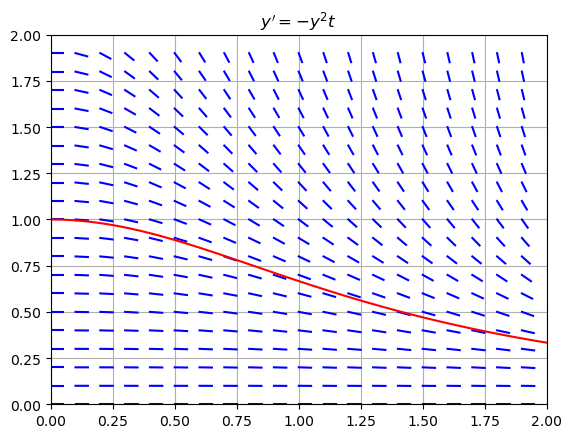

In [7]:
f = lambda t,y: -y**2*t
h = 0.1; L = 0.5*h;

t_grid = np.arange(0,2,h)
y_grid = np.arange(0,2,h)
for t in t_grid:
    for y in y_grid:
        m = f(t,y)
        theta = np.arctan(m)
        plt.plot([t,t + L*np.cos(theta)],
                 [y,y + L*np.sin(theta)],'b')

t = np.linspace(0,2)
y = 1/(t**2/2 + 1)
plt.plot(t,y,'r')
plt.title("$y' = -y^2 t$")
plt.grid(True), plt.xlim([0,2]), plt.ylim([0,2])
plt.show()

Find the unique solution of $y' - y = t$, $y(0) = 0$.

$$
y(t) = C e^{t} + At + B \Rightarrow y' = Ce^t + A = y + t = C e^{t} + At + B + t
$$
$$
y(t) = C e^{t} - t - 1
$$

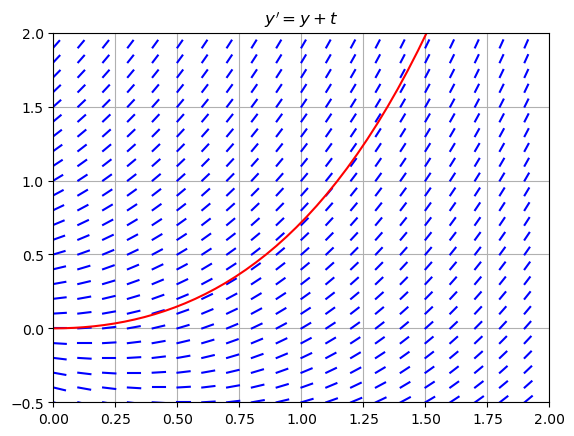

In [10]:
f = lambda t,y: y + t
h = 0.1; L = 0.5*h;

t_grid = np.arange(0,2,h)
y_grid = np.arange(-0.5,2,h)
for t in t_grid:
    for y in y_grid:
        m = f(t,y)
        theta = np.arctan(m)
        plt.plot([t,t + L*np.cos(theta)],
                 [y,y + L*np.sin(theta)],'b')

t = np.linspace(0,2)
y = np.exp(t) - t - 1
plt.plot(t,y,'r')
plt.title("$y' = y + t$")
plt.grid(True), plt.xlim([0,2]), plt.ylim([-0.5,2])
plt.show()

## Euler's Method

Consider a first order differential equation $y' = f(t,y)$, $y(t_0) = y_0$. Construct the line of slope $f(t_0,y_0)$ at point $(t_0,y_0)$:

$$
y = y_0 + f(t_0,y_0)(t - t_0)
$$

Choose a time step $h$ and let $t_1 = t_0 + h$ and define
$$
y_1 = y_0 + f(t_0,y_0)h
$$

Repeat!

$$
y_{n+1} = y_n + f(t_n,y_n)(t_{n+1} - t_n)
$$

If we choose equally spaced $t$ values we get

$$
y_{n+1} = y_n + f(t_n,y_n)h
$$


Write a function called `odeEuler` which takes function `f` (representing a first order differential equation), vector `t` of $t$ values, and initial condition `y_0`, and returns a matrix with $t$ values in the first column and $y$ values given by Euler's method in the second column.

In [13]:
def odeEuler(f,t,y0):
    y = np.zeros(len(t))
    y[0] = y0
    for n in range(len(t) - 1):
        y[n+1] = y[n] + f(t[n],y[n])*(t[n+1] - t[n])
    return np.column_stack([t,y])

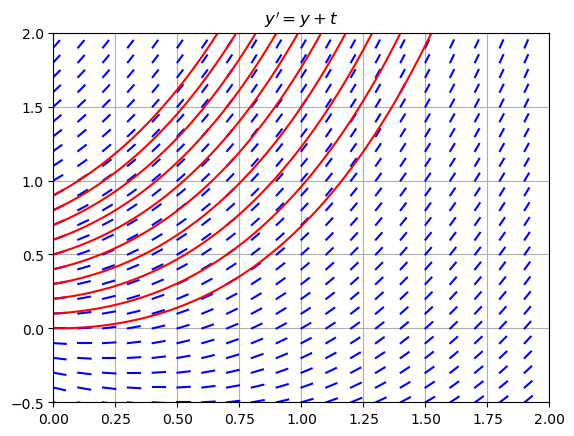

In [17]:
f = lambda t,y: y + t
h = 0.1; L = 0.5*h;

t_grid = np.arange(0,2,h)
y_grid = np.arange(-0.5,2,h)
for t in t_grid:
    for y in y_grid:
        m = f(t,y)
        theta = np.arctan(m)
        plt.plot([t,t + L*np.cos(theta)],
                 [y,y + L*np.sin(theta)],'b')

t = np.linspace(0,2,101)
for y0 in np.arange(0,1,0.1):
    result = odeEuler(f,t,y0)
    y = result[:,1]
    plt.plot(t,y,'r')
plt.title("$y' = y + t$")
plt.grid(True), plt.xlim([0,2]), plt.ylim([-0.5,2])
plt.show()

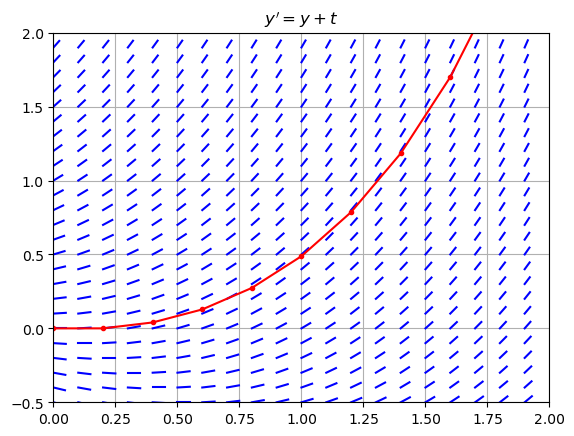

In [20]:
f = lambda t,y: y + t
h = 0.1; L = 0.5*h;

t_grid = np.arange(0,2,h)
y_grid = np.arange(-0.5,2,h)
for t in t_grid:
    for y in y_grid:
        m = f(t,y)
        theta = np.arctan(m)
        plt.plot([t,t + L*np.cos(theta)],
                 [y,y + L*np.sin(theta)],'b')

t = np.linspace(0,2,11)
result = odeEuler(f,t,0)
y = result[:,1]
plt.plot(t,y,'r.-')
plt.title("$y' = y + t$")
plt.grid(True), plt.xlim([0,2]), plt.ylim([-0.5,2])
plt.show()

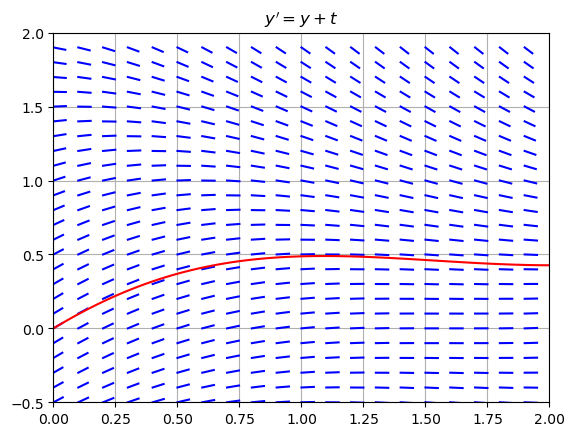

In [22]:
f = lambda t,y: np.cos(y) - np.sin(t)
h = 0.1; L = 0.5*h;

t_grid = np.arange(0,2,h)
y_grid = np.arange(-0.5,2,h)
for t in t_grid:
    for y in y_grid:
        m = f(t,y)
        theta = np.arctan(m)
        plt.plot([t,t + L*np.cos(theta)],
                 [y,y + L*np.sin(theta)],'b')

t = np.linspace(0,2,101)
result = odeEuler(f,t,0)
y = result[:,1]
plt.plot(t,y,'r')
plt.title("$y' = y + t$")
plt.grid(True), plt.xlim([0,2]), plt.ylim([-0.5,2])
plt.show()